# Minimax vs Alpha-Beta: Benchmark Analysis

Paired benchmark: both algorithms were run on the same randomly-generated positions at each depth, so differences in nodes visited or execution time are attributable to the algorithm rather than to position-to-position variation in difficulty. See `source/apps/benchmark.cpp` for how the data was generated.

This notebook:
1. Loads and reshapes the paired CSV data
2. Computes per-position speedup ratios
3. Plots nodes/time vs depth, and the ratio distribution
4. Runs statistical tests appropriate for paired, right-skewed count data


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import linregress

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Load and reshape

The CSV is in tidy long format (one row per depth/algorithm/position).
For paired analysis we pivot to wide format: one row per (depth, position),
with separate columns for each algorithm's nodes and time.

In [2]:
df = pd.read_csv("./../results/benchmark_results.csv")
display(df.head())

,depth,algorithm,position_index,nodes_visited,time_ms
0,3,minimax,0,610,26.58620
1,3,alphabeta,0,151,8.87966
2,3,minimax,1,100,4.16667
3,3,alphabeta,1,43,2.81861
4,3,minimax,2,313,13.25570


In [4]:
wide = df.pivot_table(
    index=["depth", "position_index"],
    columns="algorithm",
    values=["nodes_visited", "time_ms"]
)
wide.columns = [f"{metric}_{algo}" for metric, algo in wide.columns]
wide = wide.reset_index()
display(wide.head())


,depth,position_index,nodes_visited_alphabeta,nodes_visited_minimax,time_ms_alphabeta,time_ms_minimax
0,3,0,151.0,610.0,8.87966,26.58620
1,3,1,43.0,100.0,2.81861,4.16667
2,3,2,81.0,313.0,6.10390,13.25570
3,3,3,33.0,55.0,1.92126,1.95648
4,3,4,234.0,1854.0,18.76980,71.03870


## 2. Per-position ratios

Computed within each matched position, so position difficulty cancels out.
A ratio of 10 means minimax visited 10x as many nodes as alpha-beta on that
exact board.

In [5]:
wide["nodes_ratio"] = wide["nodes_visited_minimax"] / wide["nodes_visited_alphabeta"]
wide["time_ratio"] = wide["time_ms_minimax"] / wide["time_ms_alphabeta"]

ratio_summary = wide.groupby("depth")[["nodes_ratio", "time_ratio"]].agg(["mean", "median", "std"])
display(ratio_summary)


nodes_ratio                       time_ratio                      
             mean     median        std       mean     median        std
depth                                                                   
3        4.363485   4.039735   1.995343   2.177904   2.147250   0.842821
4        9.194660   7.754417   6.604835   4.786978   3.524077   3.504358
5       11.952742   9.094723   6.200406   4.964663   5.024839   2.163450
6       29.911361  29.707213  17.618078  35.666066  17.907224  76.611582
7       48.919751  39.708890  34.239515  22.732954  18.035194  16.652725

For **skewed** ratio data, the **geometric mean** gives a more representative measure of central tendency for ratios and exponential data than the arithmetic mean.

Derivation of the geometric mean from the arithmetic mean of log-transformed data:
\begin{align*}
    GM &= \left(\prod_{i=1}^{n} x_i\right)^{1/n} \\
    ln(GM) &= ln\left[\left(\prod_{i=1}^{n} x_i\right)^{1/n}\right] \\
    &= \frac{1}{n} \sum_{i=1}^{n} ln(x_i) = mean(ln(x_i)) \\ 
    GM &= exp(mean(ln(x_i)))   
\end{align*}

This log formula also gives us a computational advantage by not multiplying large numbers together, which can lead to overflow errors. Instead, we can take the log of each ratio, compute the arithmetic mean of the logs, and then exponentiate the result to get the geometric mean.

In [6]:
def geometric_mean(x):
    return np.exp(np.log(x).mean())

geo_summary = wide.groupby("depth")["nodes_ratio"].agg(
    arithmetic_mean="mean",
    geometric_mean=geometric_mean,
    median="median"
)
display(geo_summary)

,arithmetic_mean,geometric_mean,median
depth,,,
3,4.363485,3.937840,4.039735
4,9.194660,7.303448,7.754417
5,11.952742,10.321216,9.094723
6,29.911361,23.016029,29.707213
7,48.919751,39.484077,39.708890


## 3. Plots

### 3a. Nodes visited vs depth (log scale)

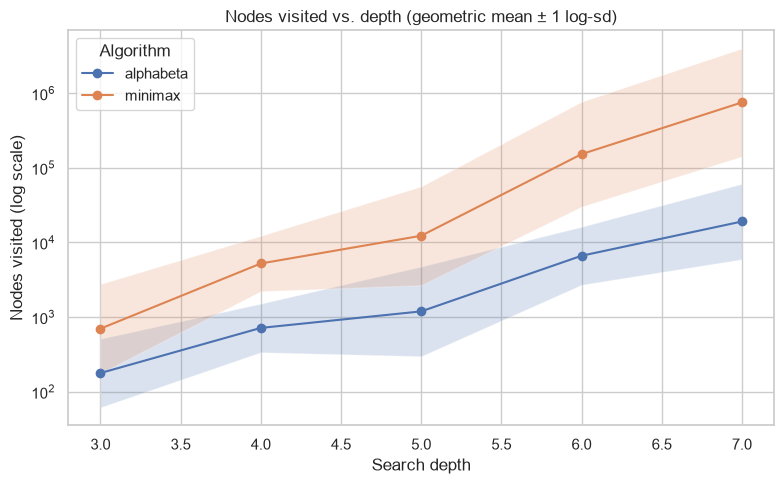

In [26]:
def geometric_band(x, n_std=1):
    """
    Compute the geometric mean and a band of n_std log standard deviations above and below the mean
    """
    log_x = np.log(x)
    mean_log, sd_log = log_x.mean(), log_x.std()

    return np.exp(mean_log - n_std * sd_log), np.exp(mean_log), np.exp(mean_log + n_std * sd_log)

fig, ax = plt.subplots(figsize=(8, 5))

for algo, group in df.groupby("algorithm"):
    depths, lows, mids, highs = [], [], [], []

    for depth, subgroup in group.groupby("depth"):
        lo, mid, hi = geometric_band(subgroup["nodes_visited"])
        depths.append(depth)
        lows.append(lo)
        mids.append(mid)
        highs.append(hi)

    ax.plot(depths, mids, marker="o", label=algo)
    ax.fill_between(depths, lows, highs, alpha=0.2)

ax.legend(title="Algorithm")

ax.set_yscale("log")
ax.set_ylabel("Nodes visited (log scale)")

ax.set_xlabel("Search depth")

ax.set_title("Nodes visited vs. depth (geometric mean ± 1 log-sd)")

plt.tight_layout()
plt.savefig("./figures/nodes_vs_depth.png")
plt.show()

### 3b. Wall-clock time vs depth (log scale)

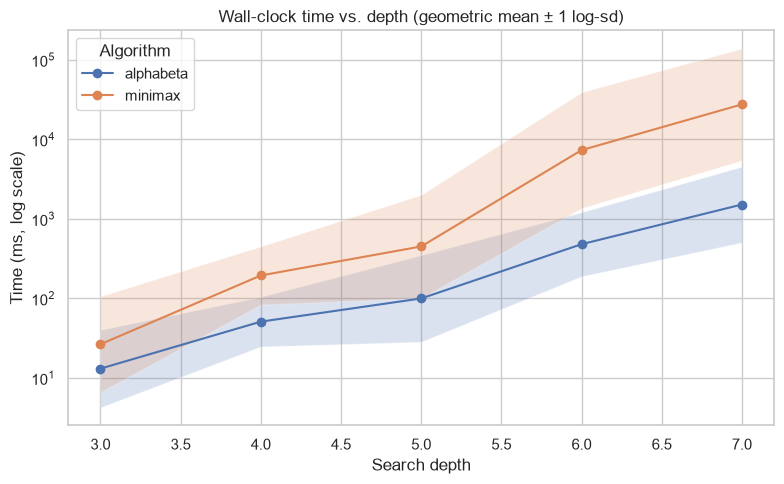

In [21]:
def geometric_band(x, n_std=1):
    log_x = np.log(x)
    mean_log, sd_log = log_x.mean(), log_x.std()

    return np.exp(mean_log - n_std * sd_log), np.exp(mean_log), np.exp(mean_log + n_std * sd_log)

fig, ax = plt.subplots(figsize=(8, 5))

for algo, group in df.groupby("algorithm"):
    depths, lows, mids, highs = [], [], [], []

    for depth, subgroup in group.groupby("depth"):
        lo, mid, hi = geometric_band(subgroup["time_ms"])
        depths.append(depth)
        lows.append(lo)
        mids.append(mid)
        highs.append(hi)

    ax.plot(depths, mids, marker="o", label=algo)
    ax.fill_between(depths, lows, highs, alpha=0.2)

ax.legend(title="Algorithm")

ax.set_yscale("log")
ax.set_ylabel("Time (ms, log scale)")

ax.set_xlabel("Search depth")

ax.set_title("Wall-clock time vs. depth (geometric mean ± 1 log-sd)")

plt.tight_layout()
plt.savefig("./figures/time_vs_depth.png", dpi=150)
plt.show()


### 3c. Speedup ratio distribution per depth
Boxplot of per-position node ratios at each depth. Shows average speedup and consistency across positions.

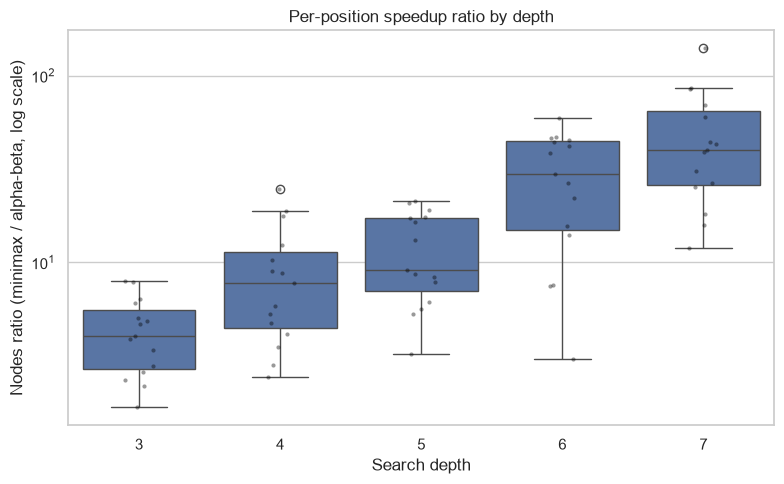

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=wide, x="depth", y="nodes_ratio", ax=ax)
sns.stripplot(data=wide, x="depth", y="nodes_ratio", color="black", alpha=0.4, size=3, ax=ax)

ax.set_yscale("log")
ax.set_ylabel("Nodes ratio (minimax / alpha-beta, log scale)")

ax.set_xlabel("Search depth")

ax.set_title("Per-position speedup ratio by depth")

plt.tight_layout()
plt.savefig("figures/ratio_by_depth.png", dpi=150)
plt.show()

## 4. Statistical tests

Node counts are highly right-skewed (roughly multiplicative growth with depth), so a paired t-test on raw counts risks being distorted by a few large values. We instead:

1. Log-transform nodes, then paired t-test on the log-difference, this tests whether the **geometric mean ratio** differs from 1, which matches how we're already describing the result ("10x fewer nodes").
2. Check the log-difference distribution visually before trusting the t-test.
3. Run the Wilcoxon signed-rank test (non-parametric test) to cross-check. If the tests disagree, the t-test's normality assumption might be violated.

In [27]:
results = []

for depth, group in wide.groupby("depth"):
    log_diff = np.log(group["nodes_visited_minimax"]) - np.log(group["nodes_visited_alphabeta"])

    # Paired t-test on log-differences (same as to testing the geometric mean ratio != 1)
    t_stat, t_p = stats.ttest_1samp(log_diff, popmean=0)

    w_stat, w_p = stats.wilcoxon(log_diff)

    n_favoring_ab = (group["nodes_visited_minimax"] > group["nodes_visited_alphabeta"]).sum()
    print(f"depth {depth}: alpha-beta won {n_favoring_ab}/{len(group)} positions")

    results.append({
        "depth": depth,
        "n_positions": len(group),
        "geometric_mean_ratio": np.exp(log_diff.mean()),
        "paired_t_pvalue": t_p,
        "wilcoxon_pvalue": w_p,
    })

stats_summary = pd.DataFrame(results)
display(stats_summary)

depth 3: alpha-beta won 15/15 positions
depth 4: alpha-beta won 15/15 positions
depth 5: alpha-beta won 15/15 positions
depth 6: alpha-beta won 15/15 positions
depth 7: alpha-beta won 15/15 positions


,depth,n_positions,geometric_mean_ratio,paired_t_pvalue,wilcoxon_pvalue
0,3,15,3.937840,2.560813e-08,0.000061
1,4,15,7.303448,3.162752e-08,0.000061
2,5,15,10.321216,3.599404e-10,0.000061
3,6,15,23.016029,1.276934e-09,0.000061
4,7,15,39.484077,6.416170e-12,0.000061


In [28]:
# Fit a linear regression to the log of the geometric mean ratio vs depth
log_ratios = np.log(ratio_summary["nodes_ratio"]["mean"].values) 
depths = ratio_summary.index.values

slope, intercept, r_value, p_value, std_err = linregress(depths, log_ratios)
print(f"slope = {slope:.3f}, r² = {r_value**2:.3f}")
print(f"implied effective branching factor reduction: {np.exp(slope):.2f}x per ply")

slope = 0.601, r² = 0.980
implied effective branching factor reduction: 1.82x per ply


### Checking the normality assumption

Before trusting the t-test result, we have to look at whether the log-differences are roughly normal. Our small sample sizes (n=15/depth) make this hard to judge definitively, but skew or heavy tails would be visible.

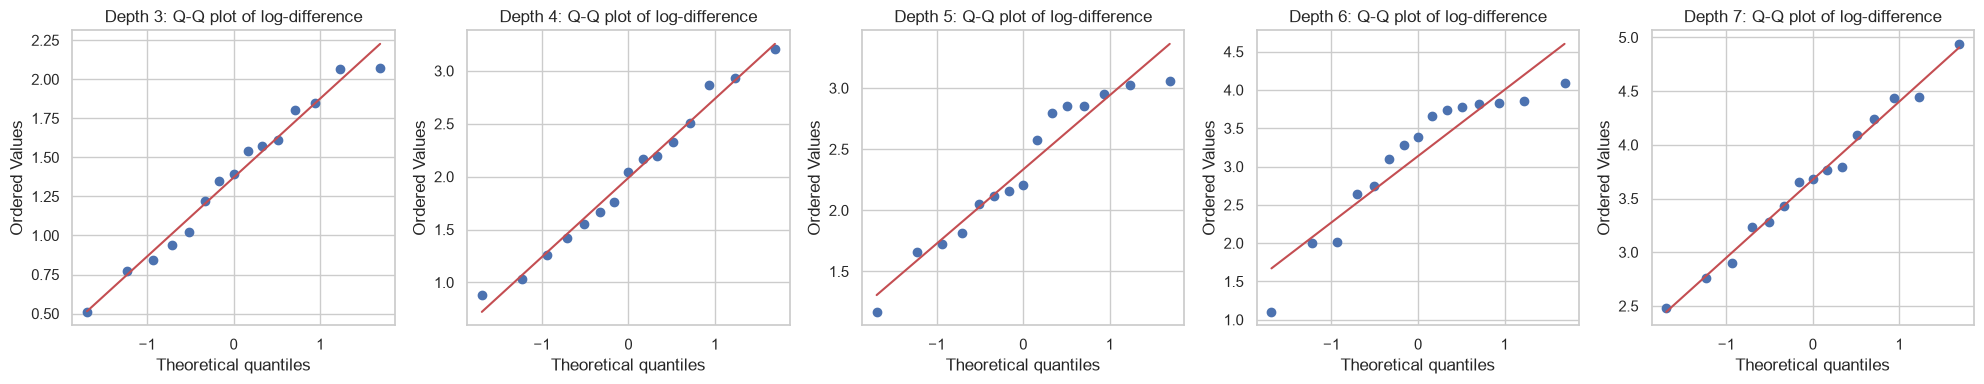

In [29]:
fig, axes = plt.subplots(1, len(wide["depth"].unique()), figsize=(4 * wide["depth"].nunique(), 4))

for ax, (depth, group) in zip(axes, wide.groupby("depth")):
    log_diff = np.log(group["nodes_visited_minimax"]) - np.log(group["nodes_visited_alphabeta"])
    
    stats.probplot(log_diff, dist="norm", plot=ax)

    ax.set_title(f"Depth {depth}: Q-Q plot of log-difference")

plt.tight_layout()
plt.savefig("figures/qq_plots.png", dpi=150)
plt.show()

## TODO
1. Summary about the results of the statistical tests and what they mean for the speedup ratio.
2. Estimating branching factor (for the current alpha-beta implementation) and compare how far away from the theoretical best case scenario we are.
3. Optimise alpha-beta (move ordering) and re-run the benchmarks to compare improvements.
